In [ ]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 20260908
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")  # force CPU for reproducibility

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.13.0+cu132
Device: cpu


# GAMEX Practical 1 - Autoregressive Transformers for Edinburgh Airport Arrivals

**Edinburgh Summer School on Generative AI for Extremes — 8 September 2026**  
**Suggested time for this Notebook:** 60 minutes

We will spend some time on Python syntax and Pytorch's tensor.
Then we will illustrate how we can fit an autoregressive transformer model for aircraft arrival trajectories.





`Python` list → general-purpose data container <br>
`NumPy` array → efficient numerical array <br>
`PyTorch` tensor → efficient numerical array + accelerators + automatic differentiation + deep-learning infrastructure

A `PyTorch` tensor is similar to a `NumPy` array, but PyTorch defines its own tensor class because neural-network training requires additional features such as GPU computation and automatic differentiation.

In [2]:
# Python list
python_data = [[1.0, 2.0], [3.0, 4.0]]

# NumPy array
numpy_data = np.array(python_data)

# PyTorch tensor
torch_data = torch.tensor(python_data)

print("Python:", python_data, type(python_data))
print("NumPy: ", numpy_data, type(numpy_data))
print("PyTorch:", torch_data, type(torch_data))

print("\nShapes:")
print("Python:", (len(python_data), len(python_data[0])))
print("NumPy: ", numpy_data.shape)
print("PyTorch:", torch_data.shape)

# Indexing is similar
print("\nFirst row:")
print("Python:", python_data[0])
print("NumPy: ", numpy_data[0])
print("PyTorch:", torch_data[0])

# Numerical operations behave differently
print("\nMultiply by 2:")
print("Python:", python_data * 2)
print("NumPy: ", numpy_data * 2)
print("PyTorch:", torch_data * 2)

# PyTorch tensors have a dtype and can be moved between devices
print("\nData types:")
print("NumPy: ", numpy_data.dtype)
print("PyTorch:", torch_data.dtype)

torch_from_numpy = torch.from_numpy(numpy_data)
torch_data = torch_from_numpy.to(device)
numpy_from_torch = torch_data.cpu().numpy()
print("PyTorch:", torch_data, type(torch_data), torch_data.device)
print("NumPy:", numpy_from_torch, type(numpy_from_torch), numpy_from_torch.dtype)

# print("\nTensor device:", torch_data.device)

Python: [[1.0, 2.0], [3.0, 4.0]] <class 'list'>
NumPy:  [[1. 2.]
 [3. 4.]] <class 'numpy.ndarray'>
PyTorch: tensor([[1., 2.],
        [3., 4.]]) <class 'torch.Tensor'>

Shapes:
Python: (2, 2)
NumPy:  (2, 2)
PyTorch: torch.Size([2, 2])

First row:
Python: [1.0, 2.0]
NumPy:  [1. 2.]
PyTorch: tensor([1., 2.])

Multiply by 2:
Python: [[1.0, 2.0], [3.0, 4.0], [1.0, 2.0], [3.0, 4.0]]
NumPy:  [[2. 4.]
 [6. 8.]]
PyTorch: tensor([[2., 4.],
        [6., 8.]])

Data types:
NumPy:  float64
PyTorch: torch.float32
PyTorch: tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) <class 'torch.Tensor'> cpu
NumPy: [[1. 2.]
 [3. 4.]] <class 'numpy.ndarray'> float64


In [3]:
x = torch.tensor([2.0], requires_grad=True)
y = (x ** 2).sum()
y.backward() #standard method for automatic differentiation to compute gradients
print(x.grad)

tensor([4.])


This notebook uses a **synthetic arrival-trajectory dataset contextualised to Edinburgh Airport**.

Edinburgh Airport has one physical runway, **06/24**. For this teaching example:

- **Runway 06:** arrivals approach from the west / south-west toward approximately 60° (East-Northeast)
- **Runway 24:** arrivals approach from the east / north-east toward approximately 240° (West-Southwest)
- Aircraft take off and land into the wind to generate optimal lift. Due to Scotland’s prevailing westerly winds, Runway 24 is the one active the majority of the time.

The trajectories are **not real ADS-B tracks and do not reproduce Edinburgh's published arrival procedures**. They are generated locally so that the practical remains reliable and offline.

The simulator captures one realistic qualitative feature:

> aircraft may be spread out and curved farther from the airport, but they progressively converge onto a common final approach before reaching the runway.


| Edinburgh Airpot Runway Path <br> (Google Maps) | Arrivals on 7th Sep 2026, 11:00am-11:04am <br> ([Flightradar](https://www.flightradar24.com/)) |
| :---: | :---: |
| <img src="figures/Edinburgh_airport_runway_num.png" alt="Runway Path" width="650"> | <img src="figures/Edinburgh_Airport_Arrival_Flightradar_speedup.gif" alt="Flightradar Arrivals" width="650"> |

## Learning goals

By the end you should be able to:

- convert continuous trajectory positions into discrete airspace tokens;
- construct shifted input/target sequences;
- explain the role of a causal mask;
- implement a small Transformer with PyTorch;
- train using next-token negative log-likelihood;
- condition generation on Runway 06 versus Runway 24;
- generate complete trajectories autoregressively;
- continue a partially observed arrival;
- investigate temperature and top-$k$ sampling;
- evaluate trajectory smoothness rather than judging samples only by appearance.


## 1. Generate synthetic Edinburgh arrivals trajectory

The code below uses a local East/North coordinate system centred on the runway.

The route geometry is deliberately simple:

1. aircraft enter the outer plotting region with a continuous range of lateral offsets;
2. a smooth curve moves them towards the extended runway centreline;
3. the final 9–14 km of the toy simulation becomes progressively straighter;
4. the trajectory finishes at the appropriate runway threshold.


In [4]:
# -------------------------------------------------------------------
# Synthetic Edinburgh Airport arrival trajectory simulator
# -------------------------------------------------------------------
#
# Real context used:
#   * Edinburgh has one physical runway, 06/24.
#   * Runway 06 arrivals approach from the west / south-west.
#   * Runway 24 arrivals approach from the east / north-east.
#
# Teaching assumptions:
#   * We generate simplified radar-vectoring-like turns onto final.
#   * These are NOT real ADS-B tracks, STARs, ILS procedures or ATC clearances.
#   * The simulator is designed only to create a realistic looking
#     distribution for learning generative modelling.
#
# Local coordinate system:
#   x = East (km)
#   y = North (km)
#   airport/runway centre = (0, 0)

N_WAYPOINTS = 30
RUNWAY_LENGTH_KM = 2.56
HALF_RUNWAY_KM = RUNWAY_LENGTH_KM / 2

HEADING_06 = 60.0
HEADING_24 = 240.0

P_RUNWAY_24 = 0.85

AIRSPACE_XLIM = (-40.0, 40.0)
AIRSPACE_YLIM = (-30.0, 30.0)

def heading_vector(deg):
    rad = math.radians(deg)
    return torch.tensor(
        [math.sin(rad), math.cos(rad)],
        dtype=torch.float32,
    )

D06 = heading_vector(HEADING_06)
D24 = heading_vector(HEADING_24)

CROSS = torch.tensor([D06[1], -D06[0]])

THRESHOLD_06 = -HALF_RUNWAY_KM * D06
THRESHOLD_24 = +HALF_RUNWAY_KM * D06

def smoothstep(q):
    q = torch.clamp(q, 0.0, 1.0)
    return q * q * (3.0 - 2.0 * q)

def make_edinburgh_arrivals(
    n_flights=4000,
    n_waypoints=N_WAYPOINTS,
    seed=SEED,
):
    g = torch.Generator().manual_seed(seed)

    trajectories = []
    runway_labels = []
    altitudes = []

    for _ in range(n_flights):
        runway = int(
            (torch.rand((), generator=g) < P_RUNWAY_24).item()
        )

        if runway == 0:
            heading = D06
            threshold = THRESHOLD_06
        else:
            heading = D24
            threshold = THRESHOLD_24

        start_distance = 28.0 + 10.0 * torch.rand((), generator=g)
        intercept_distance = 9.0 + 5.0 * torch.rand((), generator=g)

        initial_cross_track = 6.0 * torch.randn((), generator=g)
        vectoring_bend = 2.2 * torch.randn((), generator=g)
        intercept_cross_track = 0.35 * torch.randn((), generator=g)
        touchdown_cross_track = 0.05 * torch.randn((), generator=g)

        distance_to_threshold = torch.linspace(
            start_distance.item(),
            0.0,
            n_waypoints,
        )

        cross_track = torch.zeros(n_waypoints)

        for j, d in enumerate(distance_to_threshold):
            if d > intercept_distance:
                q = (d - intercept_distance) / (
                    start_distance - intercept_distance
                )
                q = torch.clamp(q, 0.0, 1.0)

                cross_track[j] = (
                    intercept_cross_track
                    + (initial_cross_track - intercept_cross_track)
                    * smoothstep(q)
                    + vectoring_bend * torch.sin(math.pi * q)
                )
            else:
                q = d / intercept_distance
                cross_track[j] = (
                    touchdown_cross_track
                    + (intercept_cross_track - touchdown_cross_track) * q
                )

        envelope = (distance_to_threshold / start_distance) ** 1.5
        cross_track += (
            0.12
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )

        xy = (
            threshold[None, :]
            - distance_to_threshold[:, None] * heading[None, :]
            + cross_track[:, None] * CROSS[None, :]
        )

        xy[-1] = threshold + touchdown_cross_track * CROSS

        altitude = (
            0.06
            + 0.055 * distance_to_threshold
            + 0.05
            * torch.randn(n_waypoints, generator=g)
            * envelope
        )
        altitude = torch.clamp(altitude, min=0.05)

        trajectories.append(xy)
        runway_labels.append(runway)
        altitudes.append(altitude)

    return (
        torch.stack(trajectories),
        torch.tensor(runway_labels).long(),
        torch.stack(altitudes),
    )

def draw_edinburgh_runway(ax=None, show_extended_final=False):
    if ax is None:
        ax = plt.gca()

    a = -HALF_RUNWAY_KM * D06
    b = +HALF_RUNWAY_KM * D06

    ax.plot(
        [a[0], b[0]],
        [a[1], b[1]],
        linewidth=6,
        solid_capstyle="butt",
        color = "steelblue",
        label="Edinburgh Airport Runway",
    )

    ax.scatter(
        [THRESHOLD_06[0], THRESHOLD_24[0]],
        [THRESHOLD_06[1], THRESHOLD_24[1]],
        marker="|",
        s=140
    )

    if show_extended_final:
        for threshold, heading in [
            (THRESHOLD_06, D06),
            (THRESHOLD_24, D24),
        ]:
            outer = threshold - 15.0 * heading
            ax.plot(
                [threshold[0], outer[0]],
                [threshold[1], outer[1]],
                linestyle="--",
                linewidth=1, color = "steelblue"
            )

def project_to_runway_coordinates(xy, runway_value):
    if runway_value == 0:
        heading = D06
        threshold = THRESHOLD_06
    else:
        heading = D24
        threshold = THRESHOLD_24

    relative = xy - threshold
    distance_to_threshold = -(relative @ heading)
    cross_track = relative @ CROSS

    return distance_to_threshold, cross_track

trajectories, runway, altitude = make_edinburgh_arrivals()

print("Dataset:", tuple(trajectories.shape))
print("RWY 06 flights:", int((runway == 0).sum()))
print("RWY 24 flights:", int((runway == 1).sum()))
print("RWY 24 fraction:", round((runway == 1).float().mean().item(), 3))


Dataset: (4000, 30, 2)
RWY 06 flights: 603
RWY 24 flights: 3397
RWY 24 fraction: 0.849


### Edinburgh context used in the simulator

Only broad airport facts are used:

- runway designation **06/24**;
- opposite arrival directions;
- a longer-run tendency to use Runway 24 more often.

The vectoring curves themselves are synthetic teaching constructs.

Official background:
- https://www.edinburghairport.com/inside-edi/all-about-edi/one-runway-but-two-directions-why-does-edinburgh-airports-arrival-and
- https://corporate.edinburghairport.com/about-us/facts-and-figures


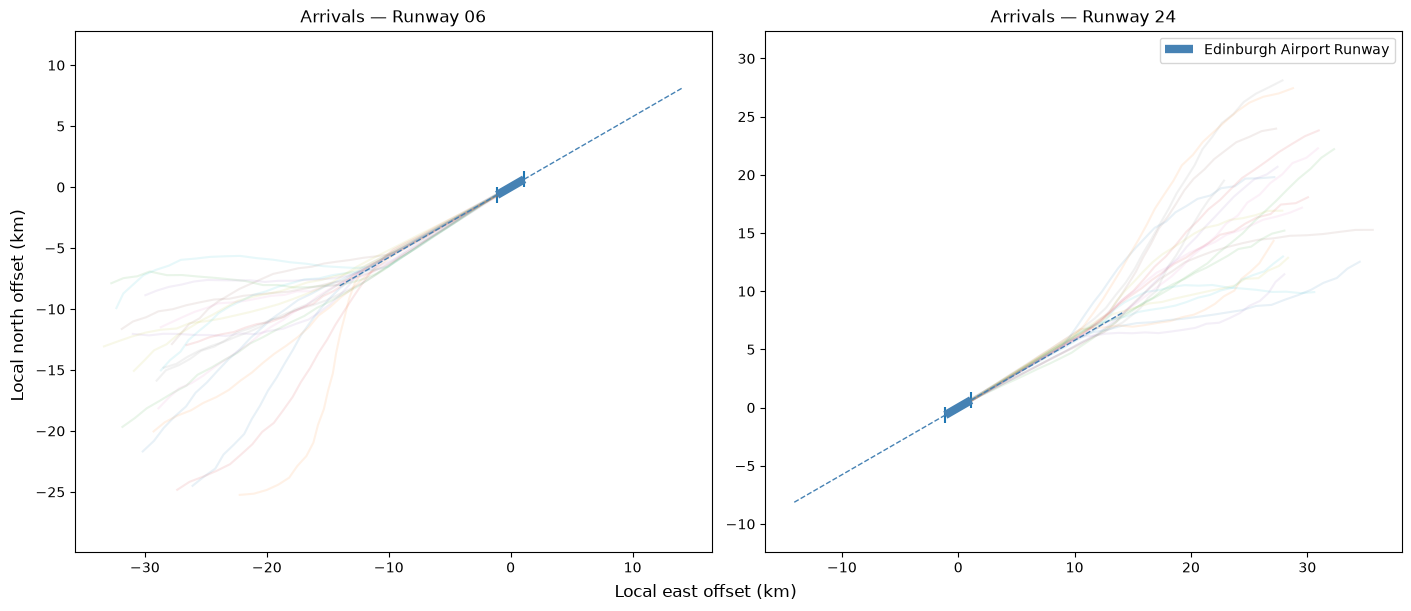

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (runway_value, label) in zip(
    axes,
    [(0, "06"), (1, "24")],
):
    for traj in trajectories[runway == runway_value][20:40]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Arrivals — Runway {label}")
    ax.set_xlim(*AIRSPACE_XLIM)
    ax.set_ylim(*AIRSPACE_YLIM)
    ax.axis("equal")

ax.legend()
fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
plt.show()

## 2. Tokenise the local airspace

Transformers model discrete tokens.

We divide the East/North plotting region into a rectangular grid. Every waypoint `(x,y)` becomes one integer cell ID.

Two extra tokens represent the runway context, `<RWY06>` or`<RWY24>`.

**Spatial discretisation**. 
The continuous airspace is partitioned into a $N_x\times N_y$ uniform grid. Each position $(x_t,y_t)$ is assigned to its containing grid cell $(i_x,i_y)$, which is encoded as the categorical token $A_t=N_xi_y+i_x$. When visualising a tokenised trajectory, each token is mapped back to the centre of its corresponding grid cell.

A finer grid improves spatial precision but increases the size and difficulty of the categorical prediction problem.


In [6]:
NX = 50
NY = 50

N_POSITION_TOKENS = NX * NY

RWY06_TOKEN = N_POSITION_TOKENS
RWY24_TOKEN = N_POSITION_TOKENS + 1
INPUT_VOCAB_SIZE = N_POSITION_TOKENS + 2

x_edges = torch.linspace(AIRSPACE_XLIM[0], AIRSPACE_XLIM[1], NX + 1)
y_edges = torch.linspace(AIRSPACE_YLIM[0], AIRSPACE_YLIM[1], NY + 1)

x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

def xy_to_tokens(xy):
    x = xy[..., 0].clamp(AIRSPACE_XLIM[0], AIRSPACE_XLIM[1] - 1e-5)
    y = xy[..., 1].clamp(AIRSPACE_YLIM[0], AIRSPACE_YLIM[1] - 1e-5)

    ix = torch.bucketize(x, x_edges[1:-1])
    iy = torch.bucketize(y, y_edges[1:-1])

    return iy * NX + ix

def tokens_to_xy(tokens):
    iy = torch.div(tokens, NX, rounding_mode="floor")
    ix = tokens % NX

    return torch.stack(
        [x_centres[ix], y_centres[iy]],
        dim=-1,
    )

position_tokens = xy_to_tokens(trajectories)

print("Spatial grid:", NX, "x", NY)
print("Position-token vocabulary:", N_POSITION_TOKENS)
print("Tokenised dataset:", tuple(position_tokens.shape))


Spatial grid: 50 x 50
Position-token vocabulary: 2500
Tokenised dataset: (4000, 30)


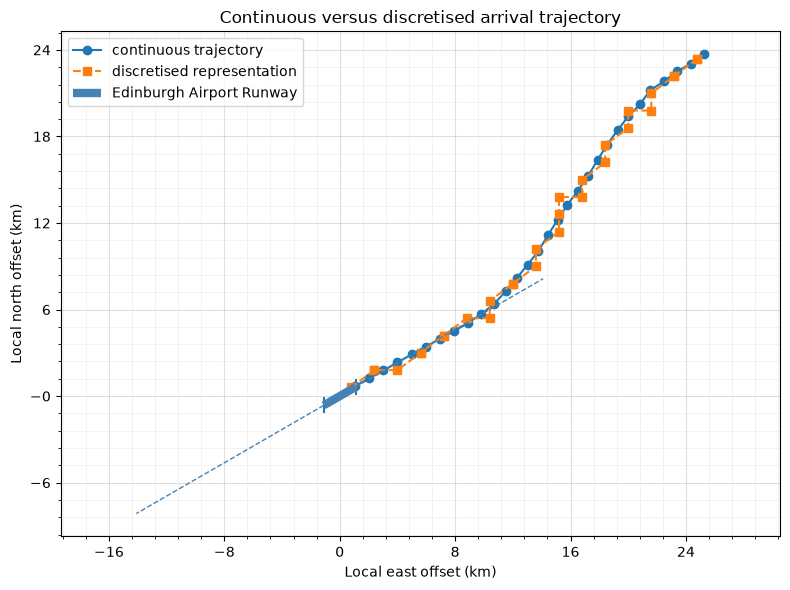

In [7]:
example_no = 7
quantised = tokens_to_xy(position_tokens[example_no])
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    trajectories[example_no, :, 0],
    trajectories[example_no, :, 1],
    marker="o",
    label="continuous trajectory",
)

ax.plot(
    quantised[:, 0],
    quantised[:, 1],
    marker="s",
    linestyle="--",
    label="discretised representation",
)
draw_edinburgh_runway(ax=ax, show_extended_final=True)

# Major ticks: every 5 spatial cells
ax.set_xticks(x_edges[::5]); ax.set_yticks(y_edges[::5])
# Minor ticks: every spatial cell boundary
ax.set_xticks(x_edges, minor=True); ax.set_yticks(y_edges, minor=True)
# Grid
ax.grid(which="major", linewidth=0.8, alpha=0.4); ax.grid(which="minor", linewidth=0.5, alpha=0.2)


ax.set_xlim(AIRSPACE_XLIM)
ax.set_ylim(AIRSPACE_YLIM)
ax.set_xlabel("Local east offset (km)")
ax.set_ylabel("Local north offset (km)")
ax.set_title("Continuous versus discretised arrival trajectory")

ax.axis("equal")
ax.legend()

plt.tight_layout()
plt.show()

### YOUR TURN 1
---

Suppose we half `NX` and `NY`.

What improves, and what becomes harder?

Consider spatial quantisation error, vocabulary size, amount of data required and next-token uncertainty.


## 3. Build autoregressive input/target sequences

For a flight with tokens

$[A_1, A_2, \ldots, A_{30}]$,

the Transformer receives

$[\mathrm{RWY}, A_1, A_2, \ldots, A_{29}]$.

After discretising the local airspace into cells, the Transformer learns

$$p(A_1,\ldots,A_{30} \mid \mathrm{RWY}) = \prod^{30}_{t=1}p(A_t \mid \mathrm{RWY}, A_{<t})$$

The goal is to model a **distribution of plausible arrivals**, not a single average path.

In [8]:
n = len(trajectories)
perm = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
n_train = int(0.80 * n)
n_val = int(0.10 * n)
idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]

def make_sequences(tokens, runway_label):
    context = torch.where(
        runway_label == 0,
        torch.tensor(RWY06_TOKEN),
        torch.tensor(RWY24_TOKEN),
    ).unsqueeze(1)

    full = torch.cat([context, tokens], dim=1)

    return full[:, :-1].long(), full[:, 1:].long()

train_inputs, train_targets = make_sequences(
    position_tokens[idx_train], runway[idx_train]
)
val_inputs, val_targets = make_sequences(
    position_tokens[idx_val], runway[idx_val]
)
test_inputs, test_targets = make_sequences(
    position_tokens[idx_test], runway[idx_test]
)

c_test = runway[idx_test]
traj_test = trajectories[idx_test]

BATCH_SIZE = 128

train_loader = DataLoader(TensorDataset(train_inputs, train_targets), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_inputs, val_targets), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(test_inputs, test_targets), batch_size=BATCH_SIZE, shuffle=False)

print("Input shape:", tuple(train_inputs.shape))
print("Target shape:", tuple(train_targets.shape))


Input shape: (3200, 30)
Target shape: (3200, 30)


## 5. Build a small Transformer

We use token embeddings, learned sequence-position embeddings, two Transformer blocks and a linear output head over the airspace-cell vocabulary.

The runway token is part of the prefix, so every subsequent location can depend on whether the aircraft is landing on Runway 06 or Runway 24.


In [9]:
class EdinburghArrivalTransformer(nn.Module):
    def __init__(
        self,
        input_vocab_size,
        output_vocab_size,
        max_seq_len,
        d_model=64,
        n_heads=4,
        n_layers=2,
        d_ff=64,
        dropout=0.10,
    ):
        super().__init__()

        self.config = {
            "input_vocab_size": input_vocab_size,
            "output_vocab_size": output_vocab_size,
            "max_seq_len": max_seq_len,
            "d_model": d_model,
            "n_heads": n_heads,
            "n_layers": n_layers,
            "d_ff": d_ff,
            "dropout": dropout,
        }

        self.token_embedding = nn.Embedding(input_vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            layer,
            num_layers=n_layers,
        )

        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(
            d_model, 
            output_vocab_size
        )

    def forward(self, tokens):
        _, seq_len = tokens.shape

        positions = torch.arange(
            seq_len,
            device=tokens.device,
        )

        h = self.token_embedding(tokens) + self.position_embedding(positions)[None, :, :]
        h = self.transformer(h, mask=causal_mask(seq_len, tokens.device))

        return self.output_head(self.norm(h))

def causal_mask(length, device):
    return torch.triu(torch.ones(length, length, dtype=torch.bool, device=device), diagonal=1)

In [10]:
mask = causal_mask(N_WAYPOINTS, device)
model = EdinburghArrivalTransformer(
    input_vocab_size=INPUT_VOCAB_SIZE,
    output_vocab_size=N_POSITION_TOKENS,
    max_seq_len=N_WAYPOINTS,
).to(device)

print("Trainable parameters:",f"{sum(p.numel() for p in model.parameters()):,}")

batch_inputs, batch_targets = next(iter(train_loader))

with torch.inference_mode():
    logits = model(batch_inputs[:4].to(device))

print("Input:", tuple(batch_inputs[:4].shape))
print("Logits:", tuple(logits.shape))

Trainable parameters: 375,108
Input: (4, 30)
Logits: (4, 30, 2500)


## 6. Train via cross-entropy loss

At each waypoint the model returns a categorical distribution over possible next cells.

Cross-entropy is the negative log-likelihood of the categorical variable (observed next location).

$$
\mathcal{L}(\mathbf{\theta})=-\frac{1}{30}\sum^{30}_{t=1}\log p_{\theta}(A_t\mid A_{<t}, \mathrm{RWY}).
$$

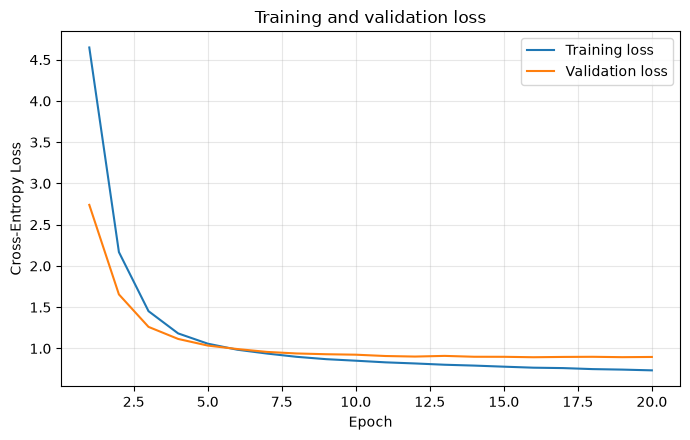

Final results: Epoch 20 | training loss 0.735 | val loss 0.897
Test NLL per waypoint: 0.906
Test perplexity (exp(NLL)): 2.47


In [ ]:
def evaluate_nll(model, loader):
    model.eval()

    evaluation_loss = 0.0
    evaluation_tokens = 0

    with torch.inference_mode():
        for batch_inputs, batch_targets in loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
            batch_logits = model(batch_inputs)

            batch_loss = F.cross_entropy(
                batch_logits.reshape(-1, N_POSITION_TOKENS),
                batch_targets.reshape(-1),
                reduction="sum",
            )

            evaluation_loss += batch_loss.item()
            evaluation_tokens += batch_targets.numel()

    return evaluation_loss / evaluation_tokens

if "optimizer" not in globals():
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=5e-3,
        weight_decay=1e-4,
    )

if "history" not in globals():
    history = {
        "train_nll": [],
        "val_nll": []
    }


N_EPOCHS = 20

start_epoch = len(history["train_nll"]) + 1
end_epoch = start_epoch + N_EPOCHS - 1

figure, axis = plt.subplots(figsize=(7, 4.5))

for epoch in range(start_epoch, end_epoch + 1):
    model.train()

    running_loss = 0.0
    running_tokens = 0.0

    for batch_inputs, batch_targets in train_loader:

        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        optimizer.zero_grad()  # resetting gradients
        batch_logits = model(batch_inputs)  # forward pass

        batch_loss = F.cross_entropy(
            batch_logits.reshape(-1, N_POSITION_TOKENS),
            batch_targets.reshape(-1),
        )  # compute loss

        batch_loss.backward()  # backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()  # update parameters

        running_loss += batch_loss.item() * batch_targets.numel()
        running_tokens += batch_targets.numel()

    train_nll = running_loss / running_tokens
    val_nll = evaluate_nll(model, val_loader)

    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)

    epochs = range(1, len(history["train_nll"]) + 1)
    axis.clear()
    axis.plot(
        epochs,
        history["train_nll"],
        label="Training loss",
    )

    axis.plot(
        epochs,
        history["val_nll"],
        label="Validation loss",
    )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("Cross-Entropy Loss")
    axis.set_title("Training and validation loss")
    axis.legend()
    axis.grid(alpha=0.3)
    figure.tight_layout()
    clear_output(wait=True)
    display(figure)

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train loss {train_nll:.3f} | "
        f"val loss {val_nll:.3f}"
    )

print(
    "Final results: "
    f"Epoch {epoch:02d}/{N_EPOCHS} | "
    f"training loss {train_nll:.3f} | "
    f"val loss {val_nll:.3f}"
)

test_nll = evaluate_nll(model, test_loader)
print(f"Test NLL per waypoint:", f"{test_nll:.3f}")
print(f"Test perplexity (exp(NLL)):", f"{math.exp(test_nll):.2f}")

### YOUR TURN 2 — How long should we train?

Try executing the code cell again.

What are happening on the training and validation loss curves?

## 7. Generate new Edinburgh arrival trajectories

Generation starts with a runway token and proceeds one spatial token at a time.

Training evaluates positions in parallel, but generation is sequential because each sampled location becomes part of the next prefix.


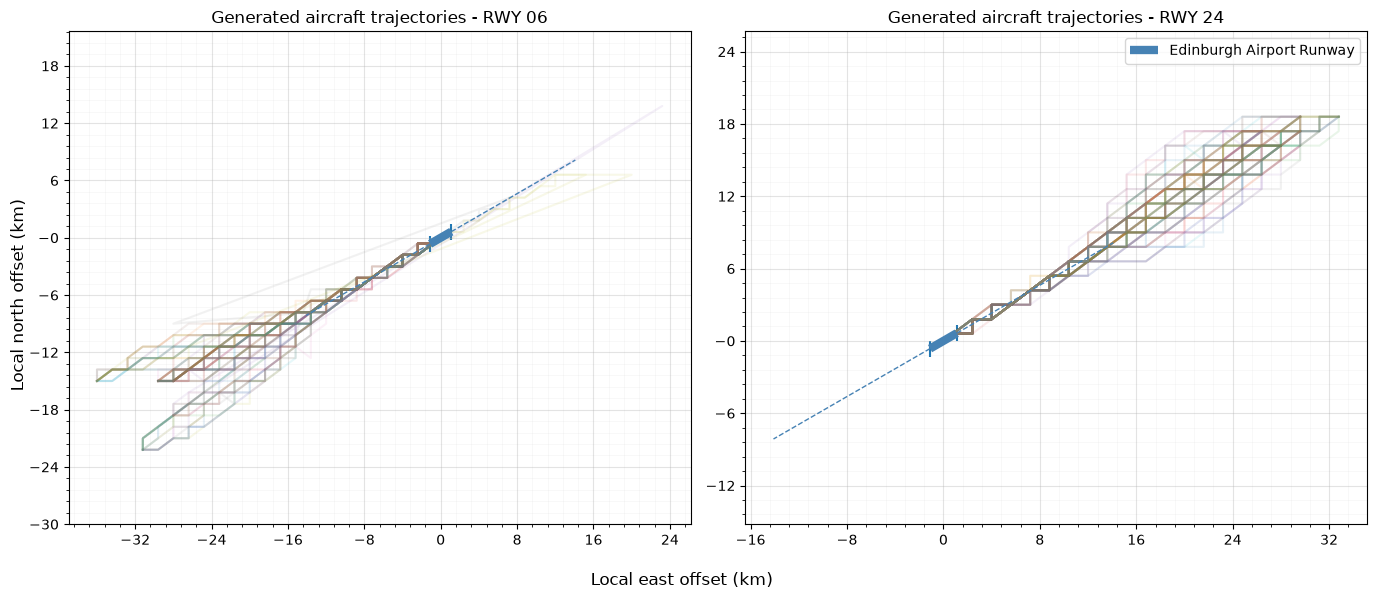

In [12]:
def sample_from_logits(logits, temperature=1.0, top_k=None):
    logits = logits / temperature

    if top_k is not None:
        k = min(int(top_k), logits.shape[-1])
        values, indices = torch.topk(logits, k=k, dim=-1)

        filtered = torch.full_like(logits, -torch.inf)
        filtered.scatter_(1, indices, values)
        logits = filtered

    probabilities = torch.softmax(logits, dim=-1)

    return torch.multinomial(probabilities, num_samples=1)

def generate_trajectory_tokens(
    model,
    n_samples,
    runway_value,
    temperature=0.8,
    top_k=5,
):
    model.eval()

    context_token = RWY06_TOKEN if runway_value == 0 else RWY24_TOKEN
    sequence = torch.full((n_samples, 1), context_token, dtype=torch.long, device=device)

    with torch.inference_mode():
        for _ in range(N_WAYPOINTS):
            logits = model(sequence)
            next_token = sample_from_logits(logits[:, -1, :], temperature=temperature, top_k=top_k)
            sequence = torch.cat([sequence, next_token], dim=1)

    return sequence[:, 1:].cpu()

generated_06 = tokens_to_xy(generate_trajectory_tokens(model, 300, runway_value=0))
generated_24 = tokens_to_xy(generate_trajectory_tokens(model, 300, runway_value=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, generated, label in zip(
    axes,
    [generated_06, generated_24],
    ["06", "24"],
):
    for traj in generated[:120]:
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.10)

    draw_edinburgh_runway(ax=ax, show_extended_final=True)
    ax.set_title(f"Generated aircraft trajectories - RWY {label}")
    ax.axis("equal")
    ax.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(x_edges[::5]))
    ax.yaxis.set_major_locator(matplotlib.ticker.FixedLocator(y_edges[::5]))
    ax.xaxis.set_minor_locator(matplotlib.ticker.FixedLocator(x_edges))
    ax.yaxis.set_minor_locator(matplotlib.ticker.FixedLocator(y_edges))
    ax.grid(which="major", linewidth=0.8, alpha=0.35)
    ax.grid(which="minor", linewidth=0.4, alpha=0.15)


fig.supxlabel("Local east offset (km)")
fig.supylabel("Local north offset (km)")
ax.legend()
plt.tight_layout()
plt.show()

### YOUR TURN 3 — temperature and top-k

Try `temperature=0.5`, `temperature=1.2` or `top_k=2`.

Look for too little diversity, large local jumps, or failure to converge smoothly toward the runway. <br>
Why are we observing some weird trajectories for `RWY06`?


## 8. Distributional diagnostic: spatial occupancy

A generated trajectory may look visually plausible while still failing to reproduce the
overall spatial distribution of the held-out arrivals.

To evaluate this, we compare the **empirical spatial occupancy distribution** of the
test trajectories with that of trajectories sampled from the Transformer.

Let $A_{n,t}\in\{0,\ldots,K-1\}$ denote the spatial token occupied by trajectory
$n$ at waypoint $t$, where $K = N_xN_y.$

For $\mathrm{RWY}$, suppose the test set contains $N_{\mathrm{RWY}}$ trajectories with
$N$ waypoints. The empirical test-set occupancy probability of spatial cell $k$ is

$$
\widehat p_{\mathrm{obs}}(k\mid R=\mathrm{RWY})
=\frac{1}{60}
\sum_{n=1}^{2}
\sum_{t=1}^{30}
\mathbf{1}\{A_{n,t}=k\}.
$$

Likewise, for trajectories generated from the transformer,

$$
\widehat p_{\mathrm{gen}}(k\mid R=\textrm{RWY})
=
\frac{1}{60}
\sum_{n=1}^{2}
\sum_{t=1}^{30}
\mathbf{1}\{\widehat A_{n,t}=k\}.
$$

Each heatmap therefore represents the fraction of all trajectory waypoints that occupy
each spatial cell.

To highlight where the generated distribution differs from the test data, we also plot

$$
D(k\mid R=\textrm{RWY})
=
\left|
\widehat p_{\mathrm{gen}}(k\mid R=\textrm{RWY})
-
\widehat p_{\mathrm{obs}}(k\mid R=\textrm{RWY})
\right|.
$$

A small value of $D(k\mid R=\textrm{RWY})$ indicates that the generated and observed
occupancy probabilities agree closely in that cell, whereas a large value indicates
a mismatch.

This diagnostic evaluates the **overall spatial distribution** of the generated
trajectories. Because all waypoints are pooled together, it does not by itself check
whether the model places probability mass at the correct waypoint in the sequence.

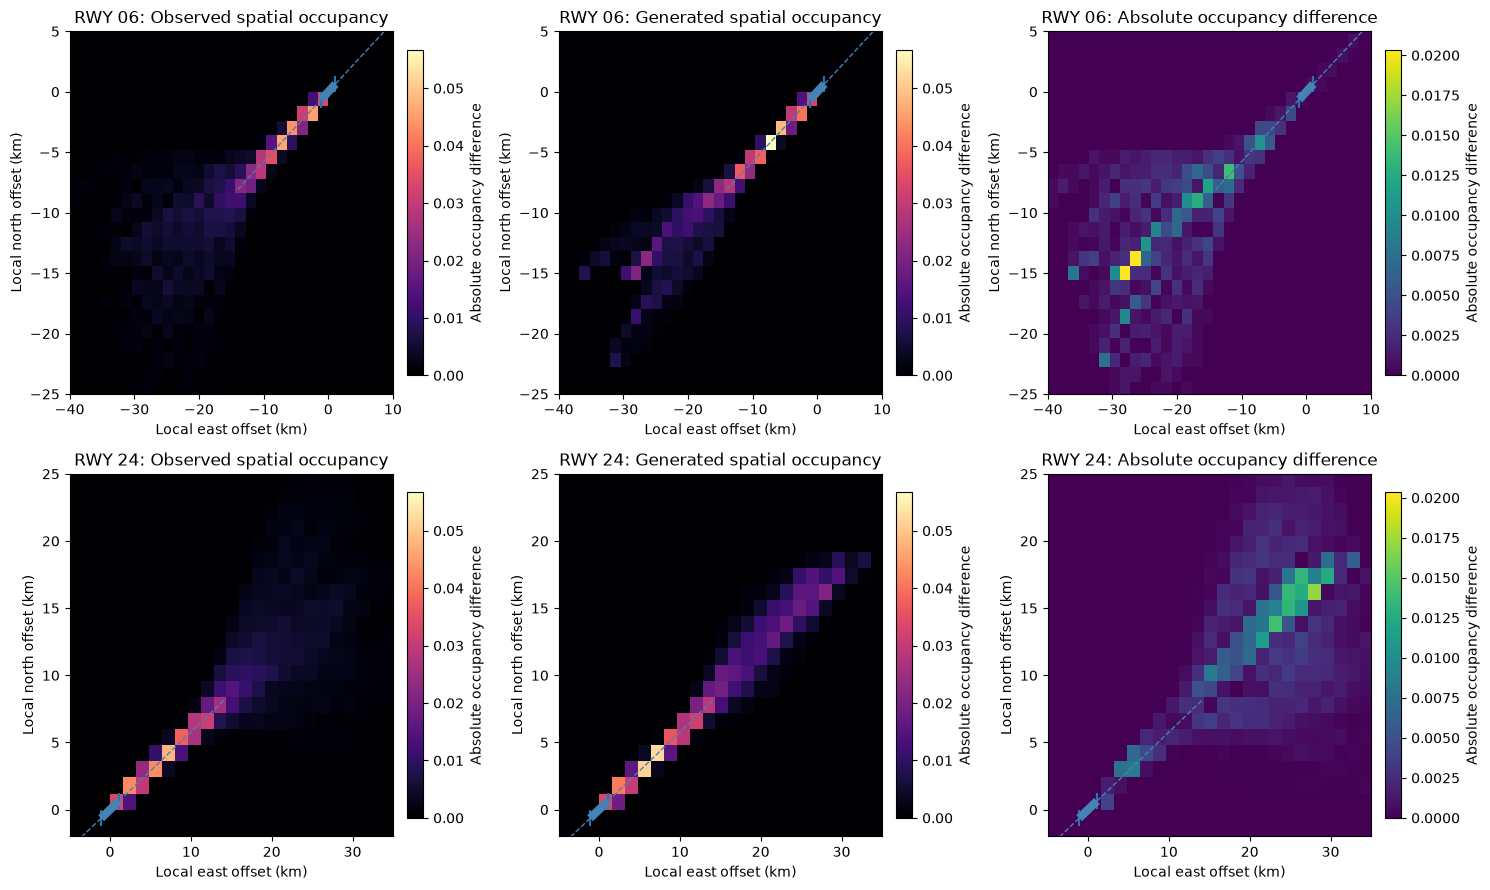

In [13]:
def occupancy_heatmap(xy):
    """
    Convert a batch of trajectories into a spatial occupancy distribution
    over the NX x NY token grid.
    """
    tokens = xy_to_tokens(xy).flatten()
    counts = torch.bincount(tokens, minlength=N_POSITION_TOKENS).float()
    heatmap = counts.reshape(NY, NX)
    heatmap = heatmap / heatmap.sum()

    return heatmap


# ---------------------------------------------------------
# Observed test trajectories by runway
# ---------------------------------------------------------
observed_06 = traj_test[c_test == 0]
observed_24 = traj_test[c_test == 1]
# Quantise observed trajectories for a fair token-level comparison
observed_06_quantised = tokens_to_xy(xy_to_tokens(observed_06))
observed_24_quantised = tokens_to_xy(xy_to_tokens(observed_24))

# ---------------------------------------------------------
# Occupancy heatmaps
# ---------------------------------------------------------
obs_06_heat = occupancy_heatmap(observed_06_quantised)
gen_06_heat = occupancy_heatmap(generated_06)
absdiff_06_heat = (gen_06_heat - obs_06_heat).abs()
obs_24_heat = occupancy_heatmap(observed_24_quantised)
gen_24_heat = occupancy_heatmap(generated_24)
absdiff_24_heat = (gen_24_heat - obs_24_heat).abs()

# ---------------------------------------------------------
# Common colour scales
# ---------------------------------------------------------
occupancy_vmax = max(obs_06_heat.max().item(), gen_06_heat.max().item(), obs_24_heat.max().item(), gen_24_heat.max().item())
abs_difference_vmax = max(absdiff_06_heat.max().item(), absdiff_24_heat.max().item())

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
rows = [("RWY 06", obs_06_heat, gen_06_heat, absdiff_06_heat, (-40, 10), (-25, 5)), ("RWY 24", obs_24_heat, gen_24_heat, absdiff_24_heat, (-5, 35), (-2, 25))]


for row, (
    runway_label,
    obs_heat,
    gen_heat,
    absdiff_heat,
    xlim,
    ylim,
) in enumerate(rows):

    panels = [
        (
            obs_heat,
            "Observed spatial occupancy",
            "magma",
            0,
            occupancy_vmax,
        ),
        (
            gen_heat,
            "Generated spatial occupancy",
            "magma",
            0,
            occupancy_vmax,
        ),
        (
            absdiff_heat,
            "Absolute occupancy difference",
            "viridis",
            0,
            abs_difference_vmax,
        )
    ]

    for col, (heat, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(
            heat.numpy(),
            origin="lower",
            extent=[
                AIRSPACE_XLIM[0],
                AIRSPACE_XLIM[1],
                AIRSPACE_YLIM[0],
                AIRSPACE_YLIM[1],
            ],
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        draw_edinburgh_runway(ax=ax, show_extended_final=True)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f"{runway_label}: {title}")
        ax.set_xlabel("Local east offset (km)")
        ax.set_ylabel("Local north offset (km)")

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Absolute occupancy difference")

plt.tight_layout()
plt.show()

## 9. Continue a partially observed arrival

Autoregressive models naturally support sequence completion.

We reveal the first four positions of a held-out Runway 24 flight and sample the remainder.

The continuation is a **sample from a conditional distribution**, not a deterministic forecast.


In [14]:
from matplotlib.animation import FuncAnimation
from matplotlib import gridspec
from IPython.display import HTML, display


def get_sampling_probabilities(
    logits,
    temperature=0.9,
    top_k=8,
):
    """
    Convert next token logits into the probability distribution
    actually used for sampling.
    """
    logits = logits / temperature

    if top_k is not None:
        k = min(int(top_k), logits.shape[-1])
        values, indices = torch.topk(logits, k=k, dim=-1)
        filtered_logits = torch.full_like(logits, -torch.inf)
        filtered_logits.scatter_(1, indices, values)
        logits = filtered_logits

    return torch.softmax(logits, dim=-1)


def complete_trajectory_with_probabilities(
    model,
    observed_prefix_xy,
    runway_value,
    temperature=0.75,
    top_k=20,
    seed=2026
):
    """
    Complete a trajectory while recording the conditional
    probability distribution used at every generation step.
    """
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    prefix_tokens = xy_to_tokens(observed_prefix_xy).long().to(device)

    context_token = RWY06_TOKEN if runway_value == 0 else RWY24_TOKEN

    sequence = torch.cat([torch.tensor([context_token], dtype=torch.long, device=device), prefix_tokens])[None, :]

    n_remaining = N_WAYPOINTS - len(prefix_tokens)
    probability_maps = []
    sampled_tokens = []

    with torch.inference_mode():
        for _ in range(n_remaining):

            # Predict the next spatial token
            logits = model(sequence)
            next_logits = logits[:, -1, :]

            # Distribution actually used for sampling
            probabilities = get_sampling_probabilities(
                next_logits,
                temperature=temperature,
                top_k=top_k
            )

            # Store the spatial probability field
            probability_maps.append(probabilities[0].reshape(NY, NX).cpu())

            # Sample one cell
            next_token = torch.multinomial(probabilities, num_samples=1, generator=generator)
            sampled_tokens.append(next_token.item())

            # Append sampled token to the sequence
            sequence = torch.cat([sequence, next_token], dim=1)

    completed_xy = tokens_to_xy(sequence[0, 1:].cpu())

    return (completed_xy, probability_maps, sampled_tokens)

# -----------------------------------------------------------
# Choose one held-out RWY 24 example
# -----------------------------------------------------------


example_idx = torch.where(c_test == 1)[0][3]
true_traj = traj_test[example_idx]

N_PREFIX = 7
prefix = true_traj[:N_PREFIX]
TEMPERATURE = 0.8
TOP_K = 5

completion, probability_maps, sampled_tokens = (
    complete_trajectory_with_probabilities(
        model,
        prefix,
        runway_value=1,
        temperature=TEMPERATURE,
        top_k=TOP_K,
    )
)


# -----------------------------------------------------------
# Compute a zoomed plotting window
# -----------------------------------------------------------

all_xy = torch.cat([true_traj, completion], dim=0).cpu().numpy()
x_min, y_min = all_xy.min(axis=0)
x_max, y_max = all_xy.max(axis=0)

pad_x = max(0.6, 0.15 * (x_max - x_min))
pad_y = max(0.6, 0.15 * (y_max - y_min))

xlim_zoom = (x_min - pad_x, x_max + pad_x)
ylim_zoom = (y_min - pad_y, y_max + pad_y)

In [15]:
# -----------------------------------------------------------
# Helper: token index -> cell centre
# -----------------------------------------------------------

def token_to_cell_centre(token):
    iy = token // NX
    ix = token % NX
    return (x_centres[ix].item(), y_centres[iy].item(), ix, iy)

# -----------------------------------------------------------
# Global probability scale
# -----------------------------------------------------------

max_probability = max(p.max().item() for p in probability_maps)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "legend.fontsize": 10
})

fig = plt.figure(figsize=(15, 7.5))
gs = fig.add_gridspec(
    nrows=2, ncols=4, width_ratios=[3.7, 0.18, 0.25, 1.45],
    height_ratios=[0.55, 2.45], wspace=0.35, hspace=0.35
)

ax_map = fig.add_subplot(gs[:, 0])
cbar_gs = gs[:, 1].subgridspec(3, 1, height_ratios=[0.5, 3, 0.5])
ax_cbar = fig.add_subplot(cbar_gs[1, 0])
ax_info = fig.add_subplot(gs[0, 3])
ax_side = fig.add_subplot(gs[1, 3])
fig.patch.set_facecolor("white")
ax_map.set_facecolor("#11151c")
ax_info.set_facecolor("#f7f8fa")
ax_side.set_facecolor("#f7f8fa")


# -----------------------------------------------------------
# Heatmap
# -----------------------------------------------------------

probability_image = ax_map.imshow(
    probability_maps[0].numpy(),
    origin="lower",
    extent=[
        AIRSPACE_XLIM[0],
        AIRSPACE_XLIM[1],
        AIRSPACE_YLIM[0],
        AIRSPACE_YLIM[1],
    ],
    interpolation="nearest",
    cmap="magma",
    vmin=0,
    vmax=max_probability,
    alpha=0.88,
    zorder=0,
)

cbar = fig.colorbar(probability_image, cax=ax_cbar)
cbar.set_label("Next cell conditional probability", labelpad=8)

ax_map.plot(
    true_traj[:, 0],
    true_traj[:, 1],
    linestyle="--",
    linewidth=2.2,
    color="0.65",
    alpha=0.95,
    label="True trajectory",
    zorder=2,
)

ax_map.plot(
    prefix[:, 0],
    prefix[:, 1],
    marker="o",
    markersize=7,
    linewidth=2.8,
    color="#4ea3ff",
    label="Observed",
    zorder=4,
)

draw_edinburgh_runway(ax=ax_map, show_extended_final=True)

# -----------------------------------------------------------
# Animated artists
# -----------------------------------------------------------
generated_line, = ax_map.plot(
    [],
    [],
    linewidth=3.0,
    linestyle="-",
    marker="o",
    markersize=5.5,
    color="#ff4d4d",
    label="Generated continuation",
    zorder=5,
)

current_point = ax_map.scatter(
    [],
    [],
    s=135,
    marker="o",
    facecolor="#ffe66d",
    edgecolor="black",
    linewidth=1.4,
    zorder=6,
)

sampled_cell = ax_map.scatter(
    [],
    [],
    s=260,
    marker="s",
    facecolor="none",
    edgecolor="white",
    linewidth=2.2,
    zorder=7,
)


# -----------------------------------------------------------
# Map formatting
# -----------------------------------------------------------
ax_map.set_xlim(xlim_zoom)
ax_map.set_ylim(ylim_zoom)
ax_map.set_aspect("equal", adjustable="datalim")
ax_map.grid(alpha=0.12, linewidth=0.9, color="white")

ax_map.set_xlabel("Local east offset (km)")
ax_map.set_ylabel("Local north offset (km)")
ax_map.set_title("Autoregressive trajectory generation on a spatial grid", pad=16)

status_text = ax_map.text(
    0.02,
    0.98,
    "",
    transform=ax_map.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor=(0, 0, 0, 0.35),
        edgecolor=(1, 1, 1, 0.15),
    ),
)

leg = ax_map.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.86),
    frameon=True,
    fancybox=True,
)
leg.get_frame().set_alpha(0.9)

ax_info.set_xticks([])
ax_info.set_yticks([])
for spine in ax_info.spines.values():
    spine.set_visible(False)

info_box = ax_info.text(
    0.03,
    0.90,
    "",
    ha="left",
    va="top",
    fontsize=11,
    transform=ax_info.transAxes,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="0.85",
    ),
)

ax_side.set_title("Top candidate next cells", pad=10)
ax_side.set_xlabel("Probability")
ax_side.grid(axis="x", alpha=0.2)
ax_side.set_axisbelow(True)


# -----------------------------------------------------------
# Animation update
# -----------------------------------------------------------
def update(frame):

    probability_grid = probability_maps[frame]
    probability_image.set_data(probability_grid.numpy())

    # Generated trajectory up to current frame
    n_generated = frame + 1
    generated_xy = completion[N_PREFIX:N_PREFIX + n_generated].cpu().numpy()
    generated_line.set_data(generated_xy[:, 0], generated_xy[:, 1])

    current_xy = completion[N_PREFIX + frame].cpu().numpy()

    current_point.set_offsets(current_xy.reshape(1, 2))
    sampled_cell.set_offsets(current_xy.reshape(1, 2))

    # Current sampled token + probability
    flat = probability_grid.flatten()
    sampled_token = sampled_tokens[frame]
    sampled_prob = flat[sampled_token].item()

    waypoint_number = N_PREFIX + frame + 1

    status_text.set_text(
        f"Waypoint {waypoint_number}/{N_WAYPOINTS}\n"
        f"Sampled next-cell probability: {100*sampled_prob:.1f}%"
    )

    info_box.set_text(
        "Generation info\n\n"
        f"Observed prefix length: {N_PREFIX}\n"
        f"Current step: {frame + 1}/{len(probability_maps)}\n"
        f"Temperature: {TEMPERATURE}\n"
        f"Top-k: {TOP_K}"
    )

    # Side bar chart
    ax_side.clear()
    ax_side.set_facecolor("#f7f8fa")
    ax_side.set_title("Top candidate next cells", pad=10)
    ax_side.set_xlabel("Probability")
    ax_side.grid(axis="x", alpha=0.2)
    ax_side.set_axisbelow(True)

    k_show = min(5, len(flat))
    topk = torch.topk(flat, k=k_show)

    top_probs = topk.values.cpu().numpy()
    top_tokens = topk.indices.cpu().numpy()

    labels = []
    for token in top_tokens:
        x_c, y_c, ix, iy = token_to_cell_centre(int(token))
        labels.append(f"({x_c:.2f}, {y_c:.2f})")

    y_pos = np.arange(k_show)
    bars = ax_side.barh(y_pos, top_probs, height=0.45)

    ax_side.set_yticks(y_pos)
    ax_side.set_yticklabels(labels, fontsize=9)
    ax_side.invert_yaxis()
    ax_side.set_xlim(0, max(0.25, top_probs.max() * 1.18))

    # Highlight the sampled token if it is in the displayed list
    for i, token in enumerate(top_tokens):
        if int(token) == int(sampled_token):
            bars[i].set_edgecolor("black")
            bars[i].set_linewidth(1.6)

    for i, p in enumerate(top_probs):
        ax_side.text(
            p + 0.01 * ax_side.get_xlim()[1],
            i,
            f"{100*p:.1f}%",
            va="center",
            fontsize=9,
        )

    return (
        probability_image,
        generated_line,
        current_point,
        sampled_cell,
        status_text,
        info_box,
    )


# -----------------------------------------------------------
# Animate
# -----------------------------------------------------------
animation = FuncAnimation(
    fig,
    update,
    frames=len(probability_maps),
    interval=1000,
    repeat=False,
    blit=False,
)

plt.close(fig)
display(HTML(animation.to_jshtml()))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


## 10. Save and reload

The spatial grid and runway-token definitions are part of the deployed representation, so they are saved alongside the neural-network weights.


In [16]:
checkpoint_path = Path("edinburgh_arrival_tf.pt")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": model.config,
    "x_edges": x_edges,
    "y_edges": y_edges,
    "runway_tokens": {
        "06": RWY06_TOKEN,
        "24": RWY24_TOKEN,
    },
}

torch.save(checkpoint, checkpoint_path)

loaded = torch.load(checkpoint_path, map_location=device, weights_only=False)
reloaded = EdinburghArrivalTransformer(**loaded["model_config"]).to(device)
reloaded.load_state_dict(loaded["model_state_dict"])
reloaded.eval()

with torch.inference_mode():
    a = model(test_inputs[:4].to(device))
    b = reloaded(test_inputs[:4].to(device))

max_difference = (a - b).abs().max().item()

print("Max prediction difference after reload:", f"{max_difference:.2e}")

Max prediction difference after reload: 0.00e+00


# Appendix: Details on generating synthetic arrival trajectory

## 1. Trajectory representation

Each synthetic arrival is represented by

$$
\mathbf{X} = (\mathbf{x}_1,\ldots,\mathbf{x}_T),
\qquad
\mathbf{x}_t=(x_t,y_t)^\top\in\mathbb{R}^2,
$$

with $T=30$ waypoints.

The simulator separates motion into:

- **along-track motion** toward the runway threshold;
- **cross-track displacement** perpendicular to the runway centreline.

---

## 2. Runway geometry

Let $\mathrm{RWY}\in\{0,1\},$

where $\mathrm{RWY}=0$ denotes `Runway 06` and $\mathrm{RWY}=1$ denotes `Runway 24`. The runway is sampled as $\mathrm{RWY}\sim \operatorname{Bernoulli}(0.85)$. For heading angle $\theta$, define

$$
\mathbf{d}(\theta)
=
\begin{pmatrix}
\sin\theta\\
\cos\theta
\end{pmatrix}.
$$

Hence, $\mathbf{d}_{06}=\mathbf{d}(60^\circ)$ and $\mathbf{d}_{24}=\mathbf{d}(240^\circ)=-\mathbf{d}_{06}.$ For runway length \(L=2.56\) km, the thresholds are
$$
\boldsymbol{\tau}_{06}
=
-\frac{L}{2}\mathbf{d}_{06},
\qquad
\boldsymbol{\tau}_{24}
=
+\frac{L}{2}\mathbf{d}_{06}.
$$

The unit cross-track direction is

$$
\mathbf{c}
=
\begin{pmatrix}
d_{06,y}\\
-d_{06,x}
\end{pmatrix}.
$$

---

## 3. Flight-specific random parameters

For each trajectory, $D_0\sim \mathrm{U}(28,38)$ and $D_I\sim \mathrm{U}(9,14)$ where $D_0$ is the initial distance to the runway threshold and $D_I$ is the final-approach interception distance.

The lateral-shape parameters are $C_0\sim\mathrm{N}(0,6^2)$, $B\sim\mathrm{N}(0,2.2^2)$, $C_I\sim\mathrm{N}(0,0.35^2)$, $C_T\sim\mathrm{N}(0,0.05^2)$ 

representing the initial cross-track offset, vectoring bend, interception offset, and threshold offset respectively.

---

## 4. Along-track progression

The distance to the threshold at waypoint $t$ is
$$
D_t=D_0\left(1-\frac{t-1}{T-1}\right),\qquad t=1,\ldots,T.
$$

Thus, $D_1=D_0$ and $D_T=0.$

---

## 5. Cross-track trajectory

Define the smoothstep function, $S(q)=3q^2-2q^3, \qquad 0\le q\le 1$.

The deterministic cross-track displacement is
$$
\widetilde C(D)
=
\begin{cases}
C_I
+
(C_0-C_I)
S\!\left(
\dfrac{D-D_I}{D_0-D_I}
\right)
+
B\sin\!\left(
\pi\dfrac{D-D_I}{D_0-D_I}
\right),
& D>D_I,\\[4mm]
C_T+(C_I-C_T)\dfrac{D}{D_I},
& 0\le D\le D_I.
\end{cases}
$$

Distance-dependent noise is added as
$$
C_t
=
\widetilde C(D_t)
+
0.12
\left(
\frac{D_t}{D_0}
\right)^{3/2}
\varepsilon_t,
\qquad
\varepsilon_t\sim\mathcal N(0,1).
$$

The noise decreases as the aircraft approaches the runway.

---

## 6. Cartesian trajectory

For the selected runway $\mathrm{RWY}$, let $\mathbf d_{\mathrm{RWY}}$ be the approach heading and $\boldsymbol{\tau}_{\mathrm{RWY}}$ the corresponding threshold.

For each $t$, the waypoint position is
$$
\boxed{
  \mathbf{x}_t=\boldsymbol{\tau}_{\mathrm{RWY}}-D_t\mathbf{d}_{\mathrm{RWY}}+C_t\mathbf{c}
}
$$

The final waypoint is then constrained to lie close to the runway threshold:
$$
\mathbf{x}_T=\boldsymbol{\tau}_{\mathrm{RWY}}+C_T\mathbf c.
$$
---

## 7. Generative interpretation

Let $\boldsymbol{\phi}=(D_0,D_I,C_0,B,C_I,C_T)$ denote the latent flight-specific parameters. The simulator defines 

$$
p(\mathbf X,\mathrm{RWY})=
p(\mathrm{RWY})
\int
p(\mathbf X\mid \mathrm{RWY},\boldsymbol{\phi})
p(\boldsymbol{\phi})
\,d\boldsymbol{\phi}.
$$

The generated trajectories therefore form a synthetic data distribution $p_{\mathrm{data}}(\mathbf X\mid \mathrm{RWY})$, which can be used to train a generative model satisfying $p_\theta(\mathbf X\mid \mathrm{RWY})\approx p_{\mathrm{data}}(\mathbf X\mid \mathrm{RWY})$.

We further tokenise the model through $Z_t=G(\mathbf{X}_t)$. Hence, we estimate,
$$
p_{\theta}(\mathbf{A}\mid\mathrm{RWY})=\prod^{N}_{t=1}p_{\theta}(A_t\mid A_{<t},\mathrm{RWY})
$$
A generated token $A_t$ is subsequently mapped to the centre of its corresponding spatial cell to obtain a plotted coordinate $\widehat{\mathbf X}_t$.
The model is trained only on the generated trajectories and runway labels; the latent simulator parameters are not provided during training. 